In [2]:
!pip install torchtt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.6/524.6 kB 34.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Running Classical FDM Solver...


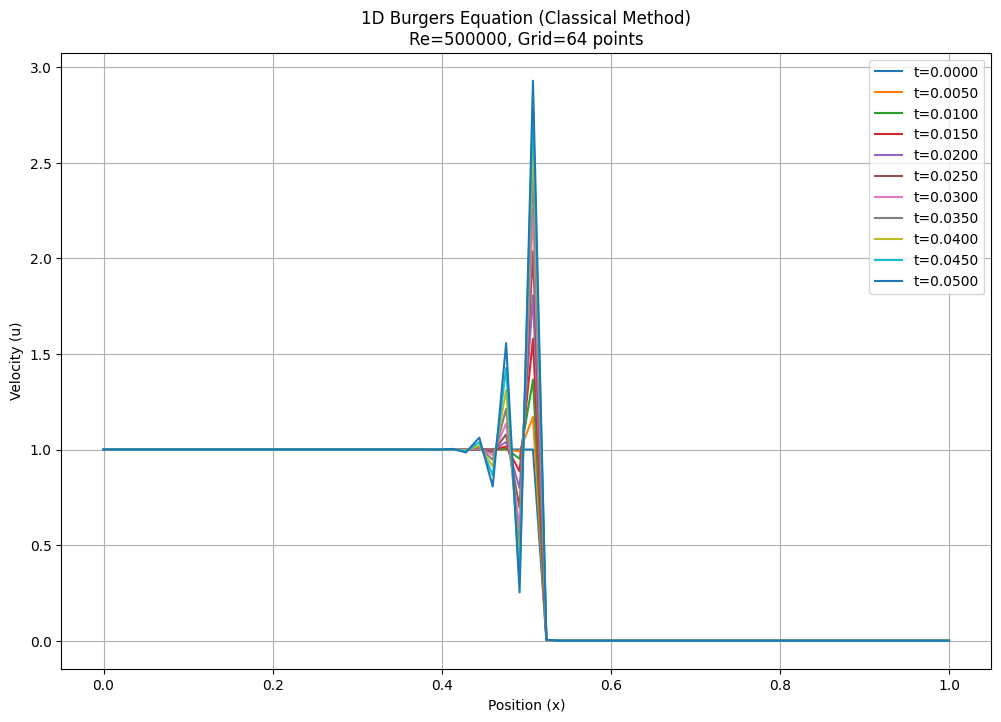

Running QTT Solver...


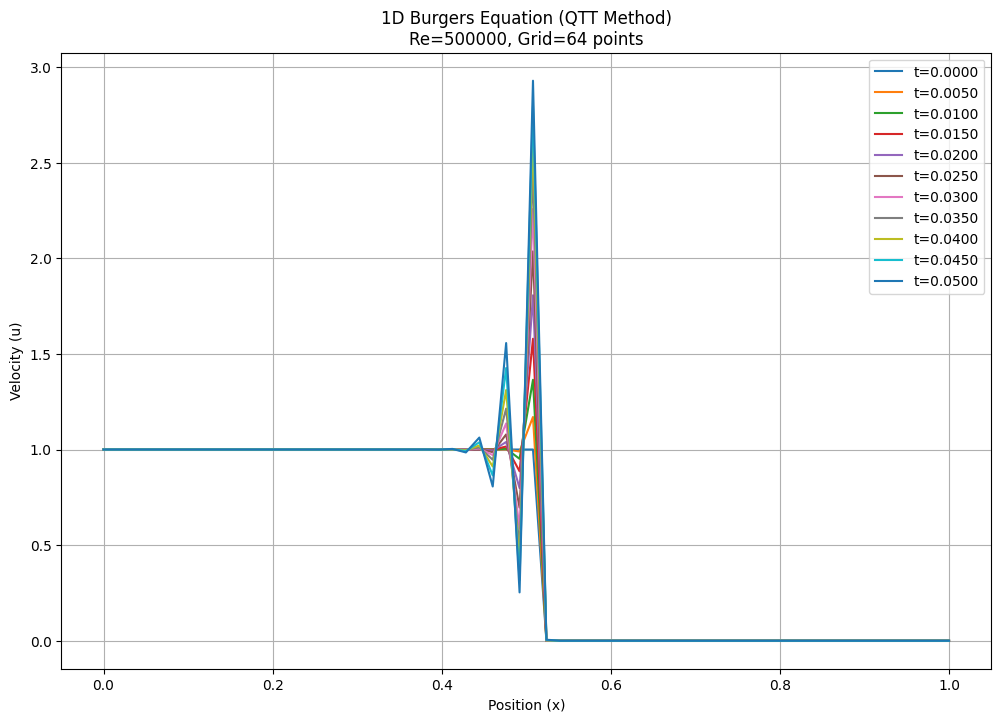


Relative error at final time: 1.6813e-09
Classical total time: 0.00 sec
QTT total time: 0.66 sec
QTT speedup: 0.00x
Classical peak memory: 1950.98 MB
QTT peak memory: 1950.98 MB
QTT memory efficiency: 1.00x

Running comprehensive performance benchmarks...

Running benchmark: c=4, Re=100

Running benchmark: c=4, Re=1000

Running benchmark: c=4, Re=10000000

Running benchmark: c=6, Re=100

Running benchmark: c=6, Re=1000

Running benchmark: c=6, Re=10000000

Running benchmark: c=8, Re=100

Running benchmark: c=8, Re=1000

Running benchmark: c=8, Re=10000000

Performance Benchmark Results:
c	Re	n	Class Time (s)	QTT Time (s)	Speedup	Class Mem (MB)	QTT Mem (MB)	QTT Rank
4	100	16	0.00	0.05	0.01	1950.9765625	1950.98	4
4	1000	16	0.00	0.05	0.01	1950.9765625	1950.98	3
4	10000000	16	0.00	0.05	0.01	1950.9765625	1950.98	3
6	100	64	0.00	0.09	0.01	1950.9765625	1950.98	4
6	1000	64	0.00	0.08	0.01	1950.9765625	1950.98	4
6	10000000	64	0.00	0.06	0.01	1950.9765625	1950.98	4
8	100	256	0.01	1.56	0.01	1950.9

In [13]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
import torch as tn
import torchtt as tntt
from matplotlib.animation import FuncAnimation
from torchtt._fast_mult import *
from IPython.display import HTML
import time
import psutil
import os

# ======================
# PHYSICAL PARAMETERS
# ======================
a = 0                  # Beginning of spatial domain
b = 1                  # End of spatial domain
c = 6                  # Number of cores in QTT (determines grid resolution: n = 2^c)
Re = 500000          # Reynolds Number (test up to 10^5-10^7)
dt = 0.001             # Time step (adjusted for stability at high Re)
t_final = 0.05         # Final simulation time
u_L = 1.0              # Left boundary condition
u_R = 0.0              # Right boundary condition

# ======================
# COMPUTATIONAL SETUP
# ======================
dx = (b-a)/(2**c)      # Grid spacing
n = 2**c               # Number of grid points
num_steps = int(t_final/dt)  # Total time steps

# ======================
# INITIAL CONDITION
# ======================
u = np.zeros(2**c)
for i in range(int((2**c)/2)+1):
    u[i] = 1

# Reshape to tensor and convert to TT format
u_r = np.reshape(u, (2,)*c)
u_tt = tntt.TT(u_r)

# ======================
# OPERATOR CONSTRUCTION
# ======================
def create_first_derivative_matrix(n, dx):
    """Create a first derivative matrix with proper boundary handling"""
    matrix = np.zeros((n, n))
    # First row (3rd order forward difference)
    matrix[0,0] = -3/(2*dx)
    matrix[0,1] = 4/(2*dx)
    matrix[0,2] = -1/(2*dx)

    # Last row (3rd order backward difference)
    matrix[n-1, n-1] = 3/(2*dx)
    matrix[n-1, n-2] = -4/(2*dx)
    matrix[n-1, n-3] = 1/(2*dx)

    # Interior points (2nd order central difference)
    for i in range(1, n-1):
        matrix[i, i-1] = -1/(2*dx)
        matrix[i, i+1] = 1/(2*dx)
    return matrix

def create_second_derivative_matrix(n, dx):
    """Create a second derivative matrix (tridiagonal)"""
    dx2 = dx**2
    matrix = np.zeros((n, n))
    # Main diagonal
    np.fill_diagonal(matrix, -2/dx2)
    # Off-diagonals
    np.fill_diagonal(matrix[:-1,1:], 1/dx2)
    np.fill_diagonal(matrix[1:,:-1], 1/dx2)
    return matrix

# Create operators
D1 = create_first_derivative_matrix(n, dx)
D2 = create_second_derivative_matrix(n, dx)

# Convert to QTT format
def operator_to_qtt(op, c):
    op_flat = op.flatten()
    op_tn = tn.from_numpy(op_flat)
    op_reshaped = tn.reshape(op_tn, [2]*(2*c))
    return tntt.TT(op_reshaped, eps=1e-12, shape=[(2,2)]*c)

D1_tt = operator_to_qtt(D1, c)
D2_tt = operator_to_qtt(D2, c)

# ======================
# CLASSICAL SOLVER (FDM)
# ======================
def classical_fdm_solver(u0, D1, D2, dt, Re, num_steps, u_L, u_R):
    """Classical Finite Difference Method solver"""
    u = u0.copy()
    solutions = [u.copy()]
    memory_usage = [psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)]
    comp_times = [0]

    for step in range(num_steps):
        start_time = time.time()

        # Compute derivatives
        u_x = D1 @ u
        u_xx = D2 @ u

        # Burgers equation: u_t = (1/Re)u_xx - u·u_x
        u_new = u + dt * ((1/Re)*u_xx - u*u_x)

        # Enforce boundary conditions
        u_new[0] = u_L
        u_new[-1] = u_R

        u = u_new
        solutions.append(u.copy())

        # Record performance
        comp_times.append(time.time() - start_time)
        memory_usage.append(psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2))

    return solutions, comp_times, memory_usage

# ======================
# QTT SOLVER
# ======================
def qtt_solver(u_tt, D1_tt, D2_tt, dt, Re, num_steps, u_L, u_R, c):
    """Quantum-inspired Tensor Train solver"""
    solutions = [u_tt.numpy().reshape(-1).copy()]
    comp_times = [0]
    memory_usage = [psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)]
    ranks = [max(u_tt.R)]  # Track maximum TT rank

    for step in range(num_steps):
        start_time = time.time()

        # Compute derivatives in QTT format
        du_tt = D1_tt @ u_tt
        du2_tt = D2_tt @ u_tt

        # Compute terms - CORRECTED ELEMENT-WISE MULTIPLICATION
        diffusion_term = (1/Re) * du2_tt
        convection_term = fast_hadammard(u_tt, du_tt, eps=1e-12)                   #u_tt * du_tt  # Use * operator instead of elementwise_mult

        # Combine and update
        RHS = diffusion_term - convection_term
        u_tt_new = u_tt + dt * RHS
        u_tt = u_tt_new.round(eps=1e-12, rmax=4)

        # Convert to full array for BC enforcement
        u_full = u_tt.numpy().reshape(-1)
        u_full[0] = u_L
        u_full[-1] = u_R

        # Update QTT with enforced BCs
        u_tt = tntt.TT(tn.tensor(u_full.reshape((2,)*c)))

        # Store solution and performance metrics
        solutions.append(u_full.copy())
        comp_times.append(time.time() - start_time)
        memory_usage.append(psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2))
        ranks.append(max(u_tt.R))

    return solutions, comp_times, memory_usage, ranks

# ======================
# PERFORMANCE BENCHMARKING
# ======================
def run_performance_comparison():
    """Compare classical and QTT solvers across different parameters"""
    results = {}
    re_numbers = [100, 1000, 10000000]
    c_values = [4, 6, 8]

    for c_val in c_values:
        for Re_val in re_numbers:
            print(f"\nRunning benchmark: c={c_val}, Re={Re_val}")
            n_val = 2**c_val
            dx_val = (b-a)/n_val

            # Adjust time step for stability at high Re
            dt_val = min(0.01, 0.5 * dx_val**2 * Re_val)
            steps_val = int(t_final/dt_val)

            # Update parameters
            D1 = create_first_derivative_matrix(n_val, dx_val)
            D2 = create_second_derivative_matrix(n_val, dx_val)
            D1_tt = operator_to_qtt(D1, c_val)
            D2_tt = operator_to_qtt(D2, c_val)

            # Initial condition
            u_init = np.zeros(n_val)
            u_init[:n_val//2] = 1
            u_tt_init = tntt.TT(tn.tensor(u_init.reshape((2,)*c_val)))

            # Run classical solver
            if n_val <= 2**12:  # Limit for classical solver
                classical_start = time.time()
                classical_solutions, classical_times, classical_mem = classical_fdm_solver(
                    u_init, D1, D2, dt_val, Re_val, steps_val, u_L, u_R
                )
                classical_total_time = time.time() - classical_start
            else:
                classical_solutions, classical_times, classical_mem = None, None, None
                classical_total_time = float('inf')

            # Run QTT solver
            qtt_start = time.time()
            qtt_solutions, qtt_times, qtt_mem, qtt_ranks = qtt_solver(
                u_tt_init, D1_tt, D2_tt, dt_val, Re_val, steps_val, u_L, u_R, c_val
            )
            qtt_total_time = time.time() - qtt_start

            # Store results
            results[(c_val, Re_val)] = {
                'n': n_val,
                'classical_time': classical_total_time,
                'classical_mem': max(classical_mem) if classical_mem else None,
                'qtt_time': qtt_total_time,
                'qtt_mem': max(qtt_mem),
                'qtt_ranks': max(qtt_ranks),
                'speedup': classical_total_time / qtt_total_time if classical_total_time != float('inf') else float('inf')
            }

    return results

# ======================
# VISUALIZATION
# ======================
def visualize_results(solutions, x, method, Re, c, dt, num_steps):
    """Visualize solution evolution and performance metrics"""
    # Solution evolution
    plt.figure(figsize=(12, 8))
    for i, sol in enumerate(solutions):
        if i % max(1, num_steps//10) == 0:  # Plot every 10% of steps
            plt.plot(x, sol, label=f"t={i*dt:.4f}")
    plt.title(f"1D Burgers Equation ({method} Method)\nRe={Re}, Grid={2**c} points")
    plt.xlabel("Position (x)")
    plt.ylabel("Velocity (u)")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"burgers_{method}_Re{Re}_c{c}.png")
    plt.show()

    # Create animation
    fig, ax = plt.subplots(figsize=(10, 6))
    line, = ax.plot(x, solutions[0])
    ax.set_ylim(-0.1, 1.1)
    ax.set_xlabel("Position (x)")
    ax.set_ylabel("Velocity (u)")
    ax.set_title(f"Burgers Equation Solution ({method}, Re={Re})")
    ax.grid(True)
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

    def update(frame):
        line.set_ydata(solutions[frame])
        time_text.set_text(f"t = {frame*dt:.4f}")
        return line, time_text

    ani = FuncAnimation(fig, update, frames=len(solutions), interval=50, blit=True)
    plt.close()
    ani.save(f"burgers_{method}_Re{Re}_c{c}.gif", writer="pillow", fps=20)

    return ani

# ======================
# MAIN SIMULATION
# ======================
if __name__ == "__main__":
    # Generate grid
    x = np.linspace(a, b, n)

    # Run classical solver (for comparison)
    if n <= 2**14:  # Only run classical for manageable grid sizes
        print("Running Classical FDM Solver...")
        classical_solutions, classical_times, classical_mem = classical_fdm_solver(
            u, D1, D2, dt, Re, num_steps, u_L, u_R
        )
        visualize_results(classical_solutions, x, "Classical", Re, c, dt, num_steps)
    else:
        print(f"Skipping classical solver for large grid (n={n})")
        classical_solutions = None

    # Run QTT solver
    print("Running QTT Solver...")
    qtt_solutions, qtt_times, qtt_mem, qtt_ranks = qtt_solver(
        u_tt, D1_tt, D2_tt, dt, Re, num_steps, u_L, u_R, c
    )
    qtt_ani = visualize_results(qtt_solutions, x, "QTT", Re, c, dt, num_steps)

    # Performance comparison
    if classical_solutions:
        # Accuracy comparison at final time
        final_error = np.linalg.norm(classical_solutions[-1] - qtt_solutions[-1]) / np.linalg.norm(classical_solutions[-1])
        print(f"\nRelative error at final time: {final_error:.4e}")

        # Runtime comparison
        classical_total = sum(classical_times)
        qtt_total = sum(qtt_times)
        print(f"Classical total time: {classical_total:.2f} sec")
        print(f"QTT total time: {qtt_total:.2f} sec")
        print(f"QTT speedup: {classical_total/qtt_total:.2f}x")

        # Memory comparison
        print(f"Classical peak memory: {max(classical_mem):.2f} MB")
        print(f"QTT peak memory: {max(qtt_mem):.2f} MB")
        print(f"QTT memory efficiency: {max(classical_mem)/max(qtt_mem):.2f}x")

    # Run performance benchmarks
    print("\nRunning comprehensive performance benchmarks...")
    benchmark_results = run_performance_comparison()

    # Display benchmark results
    print("\nPerformance Benchmark Results:")
    print("c\tRe\tn\tClass Time (s)\tQTT Time (s)\tSpeedup\tClass Mem (MB)\tQTT Mem (MB)\tQTT Rank")
    for params, res in benchmark_results.items():
        c_val, Re_val = params
        print(f"{c_val}\t{Re_val}\t{res['n']}\t"
              f"{res['classical_time']:.2f}\t{res['qtt_time']:.2f}\t"
              f"{res['speedup']:.2f}\t{res['classical_mem'] or 'N/A'}\t"
              f"{res['qtt_mem']:.2f}\t{res['qtt_ranks']}")

    # Display QTT animation in notebook
    HTML(qtt_ani.to_jshtml())